# ASE ATEK Dataset Exploration

This notebook explores the structure and contents of the **Aria Synthetic Environments (ASE)** dataset as processed by **ATEK**'s WebDataset data loader.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from pytransform3d.camera import plot_camera
from pytransform3d.plot_utils import make_3d_axis

# ATEK imports
from atek.data_loaders.atek_wds_dataloader import load_atek_wds_dataset
from atek.data_preprocess.atek_data_sample import (
    create_atek_data_sample_from_flatten_dict,
)
from atek.util.file_io_utils import load_yaml_and_extract_tar_list


## Load ATEK WebDataset Configuration

In [9]:
# Path to ASE ATEK data
data_root = Path.cwd().parent / ".data" / "ase_atek"
assert data_root.exists(), f"Data root path does not exist: {data_root}"
yaml_config = data_root / "local_train_tars.yaml"

print(f"Data root: {data_root}")
print(f"Config file: {yaml_config}")
print(f"Config exists: {yaml_config.exists()}")

# Load tar file paths from YAML
tar_paths = load_yaml_and_extract_tar_list(str(yaml_config))

# Convert to absolute paths
tar_paths = [str(data_root / tar_path) for tar_path in tar_paths]

print(f"\n✓ Found {len(tar_paths)} tar files:")
for tar_path in tar_paths:
    print(f"  - {Path(tar_path).name}")


Data root: /home/jandu/repos/NBV/.data/ase_atek
Config file: /home/jandu/repos/NBV/.data/ase_atek/local_train_tars.yaml
Config exists: True

✓ Found 15 tar files:
  - shards-0000.tar
  - shards-0001.tar
  - shards-0002.tar
  - shards-0003.tar
  - shards-0004.tar
  - shards-0005.tar
  - shards-0006.tar
  - shards-0007.tar
  - shards-0008.tar
  - shards-0009.tar
  - shards-0010.tar
  - shards-0011.tar
  - shards-0012.tar
  - shards-0013.tar
  - shards-0014.tar


## Initialize ATEK DataLoader

In [10]:
dataset = load_atek_wds_dataset(
    urls=tar_paths,
    batch_size=None,
    shuffle_flag=False,
    repeat_flag=False,
)

print(f"Dataset type: {type(dataset)}")
# print attributes of the dataset object
print(f"Dataset attributes: {[atr for atr in dir(dataset) if not atr.startswith('_')]}")


Dataset type: <class 'webdataset.compat.WebDataset'>
Dataset attributes: ['append', 'batched', 'close', 'compose', 'decode', 'extract_keys', 'invoke', 'iterator', 'iterator1', 'length', 'listed', 'lmdb_cached', 'log_keys', 'map', 'map_dict', 'map_tuple', 'mcached', 'nsamples', 'pipeline', 'rename', 'rename_keys', 'repeat', 'repetitions', 'rsample', 'select', 'shuffle', 'slice', 'stage', 'to_tuple', 'unbatched', 'unlisted', 'with_epoch', 'with_length', 'xdecode']


## Load and Inspect a Single Sample


In [11]:
# Get the first sample
sample = next(iter(dataset))

print("=" * 80)
print("SAMPLE STRUCTURE")
print("=" * 80)
print(f"\nSample keys ({len(sample)} total):")
for key in sorted(sample.keys()):
    value = sample[key]
    if isinstance(value, torch.Tensor):
        shape_str = str(tuple(value.shape))
        print(f"  {key:50s} -> Tensor {shape_str:20s} dtype={value.dtype}")
    elif isinstance(value, dict):
        print(f"  {key:50s} -> Dict with {len(value)} keys")
    elif isinstance(value, list):
        print(f"  {key:50s} -> List with {len(value)} items")
    elif isinstance(value, str):
        val_str = value[:50] + "..." if len(value) > 50 else value
        print(f"  {key:50s} -> str: '{val_str}'")
    else:
        print(f"  {key:50s} -> {type(value).__name__}")

print("\n" + "=" * 80)


SAMPLE STRUCTURE

Sample keys (54 total):
  __key__                                            -> str: 'AriaSyntheticEnvironment_82889_AtekDataSample_0000...'
  __url__                                            -> str: '/home/jandu/repos/NBV/.data/ase_atek/82889/shards-...'
  gt_data                                            -> Dict with 1 keys
  mfcd#camera-rgb+camera_label                       -> str: 'camera-rgb'
  mfcd#camera-rgb+camera_model_name                  -> str: 'CameraModelType.FISHEYE624'
  mfcd#camera-rgb+camera_valid_radius                -> Tensor (1,)                 dtype=torch.float32
  mfcd#camera-rgb+capture_timestamps_ns              -> Tensor (20,)                dtype=torch.int64
  mfcd#camera-rgb+exposure_durations_s               -> Tensor (20,)                dtype=torch.float32
  mfcd#camera-rgb+frame_ids                          -> Tensor (20,)                dtype=torch.int64
  mfcd#camera-rgb+gains                              -> Tensor (20,)       

### Explore Ground Truth Data

In [12]:
if "gt_data" in sample:
    gt_data = sample["gt_data"]
    print("Ground Truth Data Structure:")
    print("-" * 80)

    def print_nested_dict(d, indent=0):
        """Recursively print nested dictionary structure."""
        for key, value in d.items():
            if isinstance(value, dict):
                print("  " * indent + f"{key}:")
                print_nested_dict(value, indent + 1)
            elif isinstance(value, torch.Tensor):
                shape_str = str(tuple(value.shape))
                print("  " * indent + f"{key}: Tensor {shape_str} dtype={value.dtype}")
            elif isinstance(value, list):
                print("  " * indent + f"{key}: List[{len(value)}]")
                if len(value) > 0 and isinstance(value[0], torch.Tensor):
                    shape_str = str(tuple(value[0].shape))
                    print("  " * (indent + 1) + f"First item: Tensor {shape_str}")
            else:
                print("  " * indent + f"{key}: {type(value).__name__}")

    print_nested_dict(gt_data)
else:
    print("No 'gt_data' key found in sample")


Ground Truth Data Structure:
--------------------------------------------------------------------------------
efm_gt:
  0:
    camera-rgb:
      category_names: List[21]
      category_ids: Tensor (21,) dtype=torch.int64
      instance_ids: Tensor (21,) dtype=torch.int64
      object_dimensions: Tensor (21, 3) dtype=torch.float32
      ts_world_object: Tensor (21, 3, 4) dtype=torch.float32
    camera-slam-left:
      category_names: List[9]
      category_ids: Tensor (9,) dtype=torch.int64
      instance_ids: Tensor (9,) dtype=torch.int64
      object_dimensions: Tensor (9, 3) dtype=torch.float32
      ts_world_object: Tensor (9, 3, 4) dtype=torch.float32
    camera-slam-right:
      category_names: List[19]
      category_ids: Tensor (19,) dtype=torch.int64
      instance_ids: Tensor (19,) dtype=torch.int64
      object_dimensions: Tensor (19, 3) dtype=torch.float32
      ts_world_object: Tensor (19, 3, 4) dtype=torch.float32
  100000000:
    camera-rgb:
      category_names: List[21]

## Camera Parameters

In [13]:
# Find camera-related keys
camera_keys = [k for k in sample if "camera" in k.lower() or "projection" in k.lower()]
print(f"Camera-related keys: {camera_keys}\n")

for cam_key in camera_keys:
    if cam_key in sample:
        cam_data = sample[cam_key]
        print(f"{cam_key}:")
        if isinstance(cam_data, torch.Tensor):
            print(f"  Shape: {cam_data.shape}")
            print(f"  Dtype: {cam_data.dtype}")
            if cam_data.numel() < 50:  # Print if small enough # noqa: PLR2004
                print(f"  Values:\n{cam_data}")
        elif isinstance(cam_data, str):
            print(f"  Value: {cam_data}")
        elif isinstance(cam_data, dict):
            print(f"  Dict with keys: {list(cam_data.keys())}")
        print()

# Check for trajectory data
traj_keys = [
    k for k in sample if "traj" in k.lower() or "pose" in k.lower() or "t_world" in k
]
print(f"\nTrajectory-related keys: {traj_keys}")

for traj_key in traj_keys:
    if traj_key in sample:
        traj_data = sample[traj_key]
        print(f"\n{traj_key}:")
        if isinstance(traj_data, torch.Tensor):
            # Expected: [num_frames, 7] for position + quaternion
            print(f"  Shape: {traj_data.shape}")
            print(f"  First pose: {traj_data[0]}")
        else:
            print(f"  Type: {type(traj_data)}")


Camera-related keys: ['mfcd#camera-rgb+camera_label', 'mfcd#camera-rgb+camera_model_name', 'mfcd#camera-rgb+camera_valid_radius', 'mfcd#camera-rgb+capture_timestamps_ns', 'mfcd#camera-rgb+exposure_durations_s', 'mfcd#camera-rgb+frame_ids', 'mfcd#camera-rgb+gains', 'mfcd#camera-rgb+origin_camera_label', 'mfcd#camera-rgb+projection_params', 'mfcd#camera-rgb+t_device_camera', 'mfcd#camera-rgb-depth+camera_label', 'mfcd#camera-rgb-depth+capture_timestamps_ns', 'mfcd#camera-rgb-depth+frame_ids', 'mfcd#camera-rgb-depth+images', 'mfcd#camera-slam-left+camera_label', 'mfcd#camera-slam-left+camera_model_name', 'mfcd#camera-slam-left+camera_valid_radius', 'mfcd#camera-slam-left+capture_timestamps_ns', 'mfcd#camera-slam-left+exposure_durations_s', 'mfcd#camera-slam-left+frame_ids', 'mfcd#camera-slam-left+gains', 'mfcd#camera-slam-left+origin_camera_label', 'mfcd#camera-slam-left+projection_params', 'mfcd#camera-slam-left+t_device_camera', 'mfcd#camera-slam-right+camera_label', 'mfcd#camera-slam-r

### Visualize Camera Pose and Semi-Dense Points

The depth points produced by the dataset already live in the world frame. To debug our frame alignment we convert the flattened sample into a structured `AtekDataSample`, recover the RGB camera pose, and visualize it with `pytransform3d` alongside the sampled depth points.

Visualizing depth frame 1 at 100000000 ns with 4,259 points
Closest RGB frame index: 1 (Δt = 0 ns)


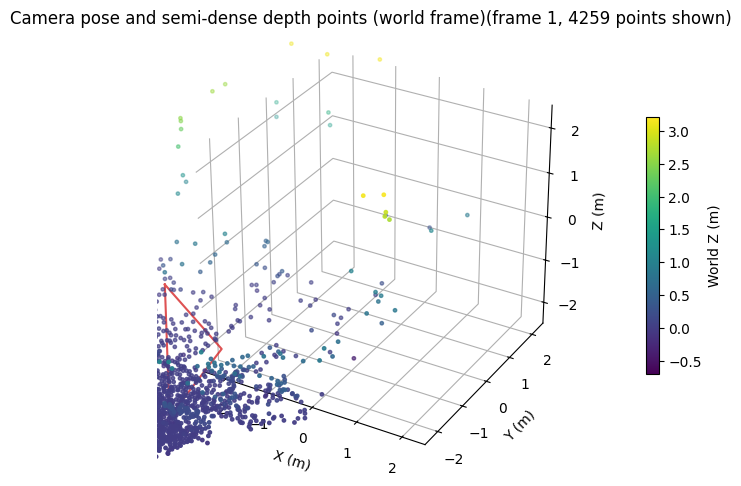

In [14]:
# Build a structured sample so we can access camera + trajectory fields easily
atek_sample = create_atek_data_sample_from_flatten_dict(sample)

cam_data = atek_sample.camera_rgb
traj_data = atek_sample.mps_traj_data
points_data = atek_sample.mps_semidense_point_data


def to_homogeneous(matrix3x4: torch.Tensor) -> np.ndarray:
    """Convert a 3x4 [R|t] block into a 4x4 homogeneous transform."""
    transform = np.eye(4, dtype=np.float64)
    transform[:3, :4] = matrix3x4.detach().cpu().numpy()
    return transform


def intrinsics_from_projection_params(
    projection_params: torch.Tensor,
    model_name: str,
) -> np.ndarray:
    """Map ATEK projection parameters to a pinhole-like intrinsic matrix."""
    params = projection_params.detach().cpu().numpy()
    model = model_name.lower()
    if "fisheye" in model and params.shape[0] >= 3:
        fx = fy = params[0]
        cx, cy = params[1], params[2]
    else:
        fx = params[0]
        fy = params[1] if params.shape[0] > 1 else params[0]
        cx = params[2] if params.shape[0] > 2 else 0.0
        cy = params[3] if params.shape[0] > 3 else 0.0
    return np.array([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=np.float64)


def first_valid_semidense_frame(points_world_list):
    """Return the index + tensor for the first frame that has finite points."""
    for idx, pts in enumerate(points_world_list):
        if not isinstance(pts, torch.Tensor):
            continue
        if pts.numel() == 0:
            continue
        valid_mask = torch.isfinite(pts).all(dim=1)
        pts = pts[valid_mask]
        if pts.numel() == 0:
            continue
        return idx, pts
    raise ValueError("No valid semi-dense point frames available in this sample.")


depth_idx, depth_points = first_valid_semidense_frame(points_data.points_world)
depth_timestamp_ns = points_data.capture_timestamps_ns[depth_idx].item()
print(
    f"Visualizing depth frame {depth_idx} at {depth_timestamp_ns} ns with {depth_points.shape[0]:,} points",
)

cam_timestamps = cam_data.capture_timestamps_ns.cpu().numpy()
frame_idx = int(np.argmin(np.abs(cam_timestamps - depth_timestamp_ns)))
print(
    f"Closest RGB frame index: {frame_idx} (Δt = {int(abs(cam_timestamps[frame_idx] - depth_timestamp_ns))} ns)"
)

T_world_device = to_homogeneous(traj_data.Ts_World_Device[frame_idx])
device_to_camera = cam_data.T_Device_Camera
if device_to_camera.dim() == 3:
    device_to_camera = device_to_camera[frame_idx]
T_device_camera = to_homogeneous(device_to_camera)
T_world_camera = T_world_device @ T_device_camera

intrinsics = intrinsics_from_projection_params(
    cam_data.projection_params,
    cam_data.camera_model_name,
)

image_width = cam_data.images.shape[-1]
image_height = cam_data.images.shape[-2]

points_world = depth_points.cpu().numpy()
max_points = 4000
if points_world.shape[0] > max_points:
    step = max(1, points_world.shape[0] // max_points)
    points_subset = points_world[::step]
else:
    points_subset = points_world

ax = make_3d_axis(ax_s=2.5)
plot_camera(
    ax=ax,
    cam2world=T_world_camera,
    M=intrinsics,
    sensor_size=(image_width, image_height),
    alpha=0.8,
    color="tab:red",
)
sc = ax.scatter(
    points_subset[:, 0],
    points_subset[:, 1],
    points_subset[:, 2],
    c=points_subset[:, 2],
    s=6,
    cmap="viridis",
)

ax.set_title(
    "Camera pose and semi-dense depth points (world frame)"
    f"(frame {depth_idx}, {points_subset.shape[0]} points shown)"
)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
fig = ax.get_figure()
fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label="World Z (m)")
fig.tight_layout()
plt.show()


In [ ]:
atek_sample


AtekDataSample(sequence_name='82889', camera_rgb=MultiFrameCameraData(images=tensor([[[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],

         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],

         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]],


        [[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0

## Explore Semi-Dense Point Cloud Data

In [15]:
# Find point cloud keys (MSDPD = Multi-Scale Dense Point Data)
pc_keys = [k for k in sample if "msdpd" in k.lower() or "points" in k]
print(f"Point cloud related keys: {pc_keys}\n")

for pc_key in pc_keys:
    if pc_key in sample:
        pc_data = sample[pc_key]
        print(f"{pc_key}:")
        if isinstance(pc_data, torch.Tensor):
            print(f"  Shape: {pc_data.shape}")
            print(f"  Dtype: {pc_data.dtype}")
            if "world" in pc_key and pc_data.ndim >= 2:  # noqa: PLR2004
                print("  Point cloud bounds:")
                print(
                    f"    X: [{pc_data[..., 0].min():.3f}, {pc_data[..., 0].max():.3f}]"
                )
                print(
                    f"    Y: [{pc_data[..., 1].min():.3f}, {pc_data[..., 1].max():.3f}]"
                )
                print(
                    f"    Z: [{pc_data[..., 2].min():.3f}, {pc_data[..., 2].max():.3f}]"
                )
        elif isinstance(pc_data, list):
            print(f"  List with {len(pc_data)} items")
            if len(pc_data) > 0 and isinstance(pc_data[0], torch.Tensor):
                print(f"  First item shape: {pc_data[0].shape}")
                print(f"  Total points: {sum(item.shape[0] for item in pc_data)}")
        else:
            print(f"  Type: {type(pc_data)}")
        print()


Point cloud related keys: ['msdpd#capture_timestamps_ns', 'msdpd#points_dist_std+stacked', 'msdpd#points_inv_dist_std+stacked', 'msdpd#points_volumn_max', 'msdpd#points_volumn_min', 'msdpd#points_world+stacked', 'msdpd#points_world_lengths', 'msdpd#points_world', 'msdpd#points_inv_dist_std', 'msdpd#points_dist_std']

msdpd#capture_timestamps_ns:
  Shape: torch.Size([20])
  Dtype: torch.int64

msdpd#points_dist_std+stacked:
  Shape: torch.Size([252745])
  Dtype: torch.float32

msdpd#points_inv_dist_std+stacked:
  Shape: torch.Size([252745])
  Dtype: torch.float32

msdpd#points_volumn_max:
  Shape: torch.Size([3])
  Dtype: torch.float32

msdpd#points_volumn_min:
  Shape: torch.Size([3])
  Dtype: torch.float32

msdpd#points_world+stacked:
  Shape: torch.Size([252745, 3])
  Dtype: torch.float32
  Point cloud bounds:
    X: [nan, nan]
    Y: [nan, nan]
    Z: [nan, nan]

msdpd#points_world_lengths:
  Shape: torch.Size([20])
  Dtype: torch.int64

msdpd#points_world:
  List with 20 items
  Fi

## Explore Batch Structure

In [16]:
# Create a batched dataset
batch_size = 2  # noqa: PLR2004
batched_dataset = load_atek_wds_dataset(
    urls=tar_paths,
    batch_size=batch_size,
    shuffle_flag=False,
    repeat_flag=False,
)

# Get one batch
batch = next(iter(batched_dataset))

print(f"Batch size: {batch_size}")
print("\nBatch structure:")
print("=" * 80)

for key in sorted(batch.keys()):
    value = batch[key]
    if isinstance(value, torch.Tensor):
        shape_str = str(tuple(value.shape))
        print(f"  {key:50s} -> Tensor {shape_str:25s} dtype={value.dtype}")
    elif isinstance(value, list):
        print(f"  {key:50s} -> List[{len(value)}]")
        if len(value) > 0:
            item = value[0]
            if isinstance(item, torch.Tensor):
                shape_str = str(tuple(item.shape))
                print(f"  {'':50s}    First item: Tensor {shape_str}")
            elif isinstance(item, dict):
                print(f"  {'':50s}    First item: Dict with {len(item)} keys")
            else:
                print(f"  {'':50s}    First item: {type(item).__name__}")
    elif isinstance(value, dict):
        print(f"  {key:50s} -> Dict with {len(value)} keys")
    else:
        print(f"  {key:50s} -> {type(value).__name__}")

print("\n" + "=" * 80)


Tensors for msdpd#points_dist_std+stacked have different shapes or dtypes, cannot be stacked, keep as a list
Tensors for msdpd#points_inv_dist_std+stacked have different shapes or dtypes, cannot be stacked, keep as a list
Tensors for msdpd#points_world+stacked have different shapes or dtypes, cannot be stacked, keep as a list
Batch size: 2

Batch structure:
  __key__                                            -> List[2]
                                                        First item: str
  __url__                                            -> List[2]
                                                        First item: str
  gt_data                                            -> List[2]
                                                        First item: Dict with 1 keys
  mfcd#camera-rgb+camera_label                       -> List[2]
                                                        First item: str
  mfcd#camera-rgb+camera_model_name                  -> List[2]
                   